# Logistic Regression (Word2Vec)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD
import nltk
from nltk.stem import WordNetLemmatizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [9]:
df_songs = pd.read_csv('dataset.csv')

In [3]:
df_songs['lyrics_tokenized'] = df_songs['lyrics_cleaned'].apply(word_tokenize)

In [4]:

# Assuming 'tokenized_sentences' is your prepared data
word_2_vec_model = Word2Vec(sentences=df_songs['lyrics_tokenized'], vector_size=300, window=5, min_count=1, workers=4)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [5]:
word_2_vec_model.save("word2vec.word_2_vec_model")
word_2_vec_model = Word2Vec.load("word2vec.word_2_vec_model")

In [6]:
#word2vec
def avg_feature_vector(words, model, num_features):
    n_words = 0
    feature_vec = np.zeros((num_features, ), dtype='float32')
    for word in words:
        try:
            n_words += 1
            feature_vec = np.add(feature_vec, model.wv[word])
        except KeyError:
            pass
    return(feature_vec/n_words)

In [7]:
dim = word_2_vec_model.vector_size
df_songs['avg_w2v'] = df_songs.apply(lambda row: avg_feature_vector(row['lyrics_tokenized'],word_2_vec_model,dim), axis=1)

In [41]:
# 3. Any nulls?
print(df_songs['avg_w2v'].isna().sum())


0


In [8]:
labels = df_songs['parent_genre'].values
feats =  np.vstack(df_songs['avg_w2v'].values)
X_train, X_test, y_train, y_test = train_test_split(
    feats, labels, test_size=0.2, random_state=42, stratify=labels
)
lr_clf = LogisticRegression()
lr_clf.fit(X_test, y_train)

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
#for top 3
def in_top(pred_list,actual, top_x):
    return True if actual in list(pred_list.keys())[:top_x] else False





def logistic_reg_and_score(df: pd.DataFrame, num_words: int, n_grams:tuple =(1,1)):
    # Split the data into features (X) and target (y)
    X = df['lyrics_cleaned']
    y = df['parent_genre']

    # Split into training and test sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Create a pipeline: Vectorizer -> Logistic Regression
    # We use 'lbfgs' solver which is good for multiclass problems
    model_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=num_words, ngram_range=n_grams)),
        ('clf', LogisticRegression(solver='lbfgs', max_iter=1000,class_weight='balanced'))
    ])

    # Train the model
    print("Training model...")
    model_pipeline.fit(X_train, y_train)

    # Make predictions
    predictions = model_pipeline.predict(X_test)

    # Evaluate
    print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, predictions))

    # Get the probabilities
    probs = model_pipeline.predict_proba(X_test)
    y_top = model_pipeline.predict(X_test)
    # Get the genre names from the model
    genres = model_pipeline.classes_

    # Create a DataFrame where each column is a Genre
    y_prob = pd.DataFrame(probs, columns=genres, index=X_test.index)
    # This creates a dictionary of {Genre: Probability} for the top 3
    y_prob['predicted'] = y_prob.apply(
        lambda row: row.nlargest(3).to_dict(), 
        axis=1
    )

    df_pred = pd.DataFrame({
        'actual': y_test
    })
    df_pred['top'] = y_top
    df_pred = df_pred.join(y_prob['predicted'])
    for x in range(1,4):
        df_pred[f'top_{x}'] = df_pred.apply(lambda row: in_top(row['predicted'],row['actual'],x), axis=1)

    return df_pred, model_pipeline

In [7]:
pred, model_pipeline = logistic_reg_and_score(df_songs,9000,(1,1))

Training model...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


Accuracy: 0.39

Classification Report:

                  precision    recall  f1-score   support

       Asian Pop       0.39      0.47      0.43        96
       Classical       0.09      0.32      0.14        44
      Electronic       0.58      0.30      0.40       882
    Folk/Country       0.44      0.56      0.49       322
   Hip-Hop & R&B       0.21      0.62      0.32        29
    Jazz & Blues       0.13      0.32      0.19        57
           Metal       0.55      0.71      0.62       452
             Pop       0.21      0.24      0.22       285
Reggae/Caribbean       0.44      0.51      0.47        86
            Rock       0.27      0.15      0.19       493
       Soul/Funk       0.19      0.31      0.23       157
  World/Regional       0.66      0.67      0.67       172

        accuracy                           0.39      3075
       macro avg       0.35      0.43      0.36      3075
    weighted avg       0.43      0.39      0.39      3075



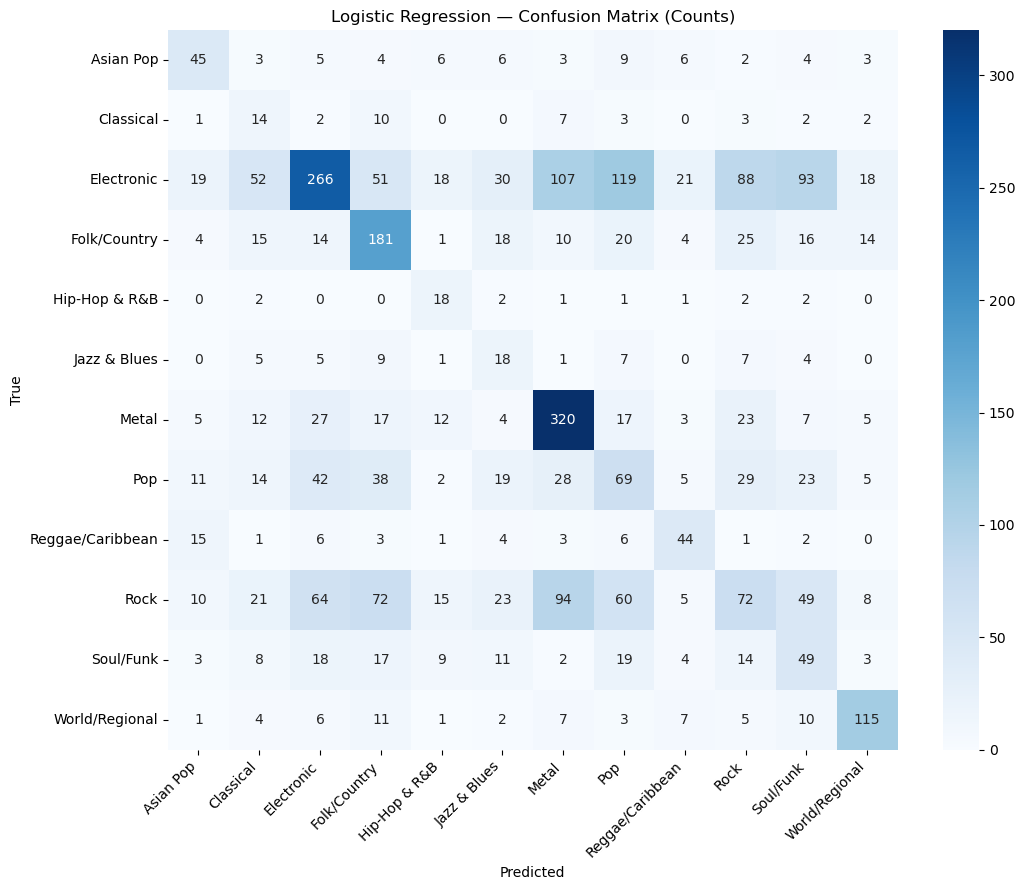

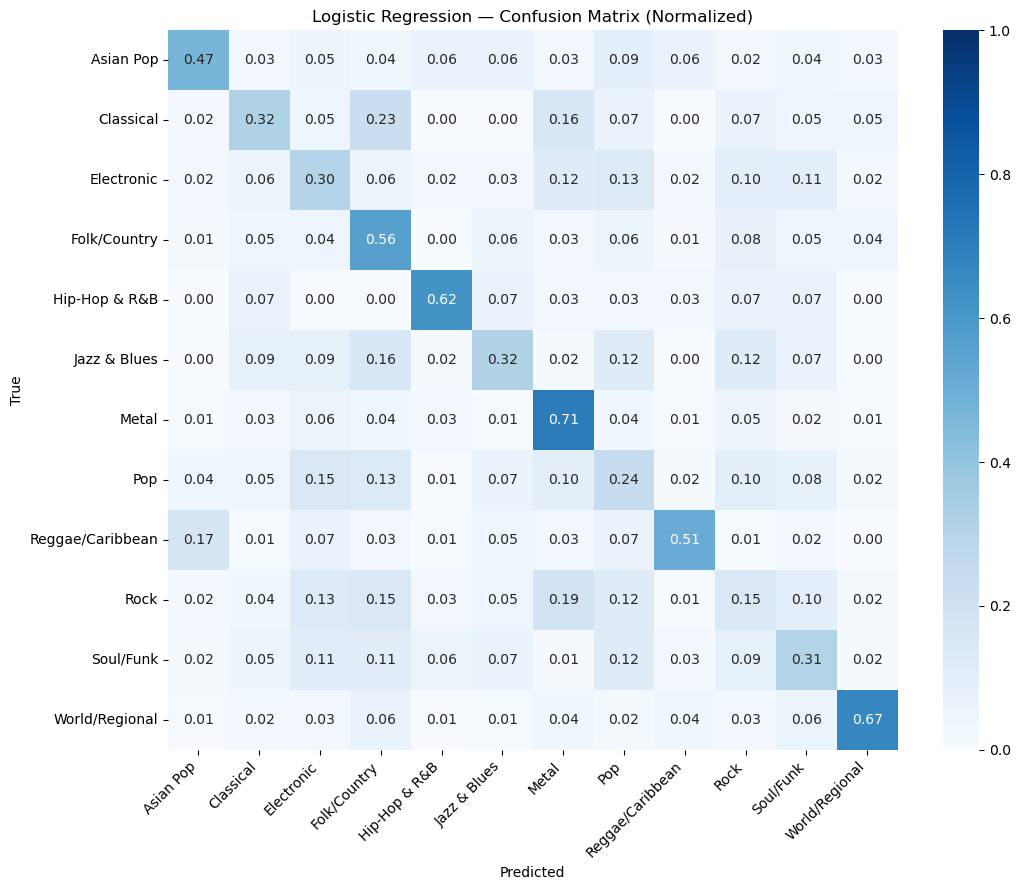

In [ ]:
# Confusion Matrix

# Force EVERY element to a Python string. No exceptions, no edge cases.
y_test_arr      = np.array([str(x) for x in pred['actual'].to_list()], dtype=object)
predictions_arr = np.array([str(x) for x in pred['top'].to_list()], dtype=object)
class_names     = [str(c) for c in model_pipeline.classes_]

conf_matrix = confusion_matrix(y_test_arr, predictions_arr, labels=class_names)

# Heatmap
plt.figure(figsize=(11, 9))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix (Counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Normalized version
conf_matrix_norm = confusion_matrix(
    y_test_arr, predictions_arr, labels=class_names, normalize="true"
)

plt.figure(figsize=(11, 9))
sns.heatmap(
    conf_matrix_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression — Confusion Matrix (Normalized)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
num_words = []
top_1 = []
top_2 = []
top_3 = []

for x in range(7000,12500,500):
    pred = logistic_reg_and_score(df_songs,x)
    num_words.append(x)
    top_1.append(pred['top_1'].mean())
    top_2.append(pred['top_2'].mean())
    top_3.append(pred['top_3'].mean())

final_opt = pd.DataFrame({
    'num_words':num_words,
    'top_1_acc': top_1,
    'top_2_acc': top_2,
    'top_3_acc': top_3
})


Training model...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


Accuracy: 0.39

Classification Report:

                  precision    recall  f1-score   support

       Asian Pop       0.40      0.46      0.43        96
       Classical       0.10      0.36      0.16        44
      Electronic       0.59      0.30      0.40       882
    Folk/Country       0.45      0.56      0.50       322
   Hip-Hop & R&B       0.21      0.62      0.31        29
    Jazz & Blues       0.13      0.32      0.18        57
           Metal       0.55      0.70      0.61       452
             Pop       0.20      0.24      0.22       285
Reggae/Caribbean       0.44      0.51      0.47        86
            Rock       0.27      0.15      0.19       493
       Soul/Funk       0.19      0.31      0.23       157
  World/Regional       0.67      0.67      0.67       172

        accuracy                           0.39      3075
       macro avg       0.35      0.43      0.37      3075
    weighted avg       0.43      0.39      0.39      3075

Training model...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


Accuracy: 0.39

Classification Report:

                  precision    recall  f1-score   support

       Asian Pop       0.40      0.46      0.43        96
       Classical       0.10      0.34      0.15        44
      Electronic       0.58      0.30      0.40       882
    Folk/Country       0.44      0.56      0.50       322
   Hip-Hop & R&B       0.21      0.62      0.32        29
    Jazz & Blues       0.13      0.32      0.18        57
           Metal       0.55      0.70      0.61       452
             Pop       0.20      0.24      0.22       285
Reggae/Caribbean       0.44      0.51      0.47        86
            Rock       0.27      0.15      0.19       493
       Soul/Funk       0.18      0.31      0.23       157
  World/Regional       0.67      0.67      0.67       172

        accuracy                           0.39      3075
       macro avg       0.35      0.43      0.36      3075
    weighted avg       0.43      0.39      0.39      3075

Training model...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


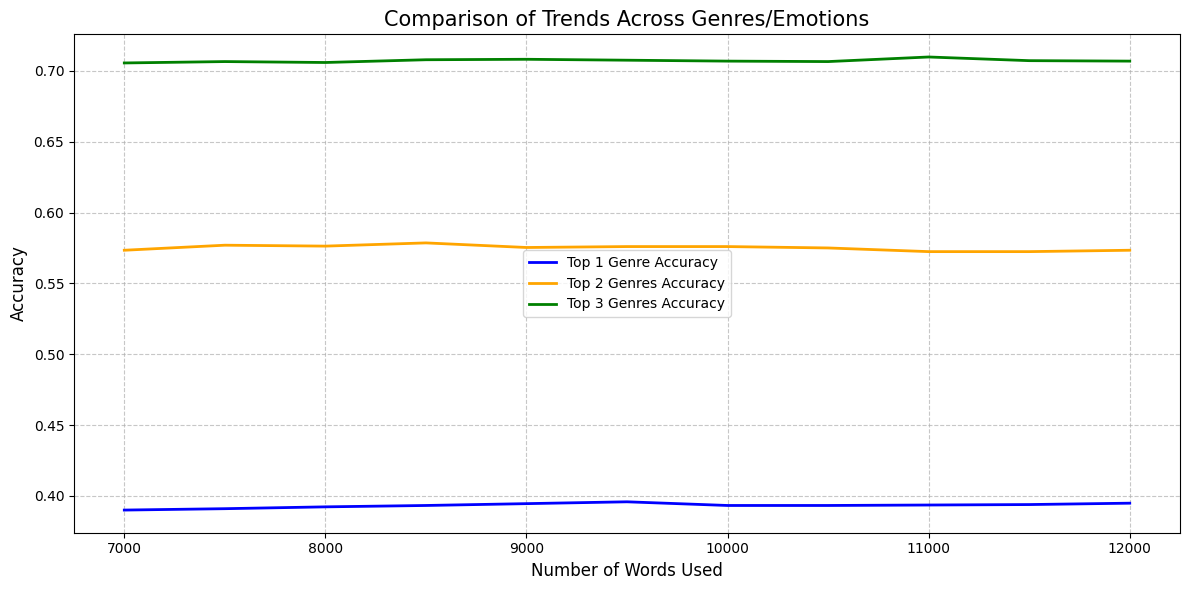

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the size of the plot
plt.figure(figsize=(12, 6))

# 2. Plot each column
# We use the dataframe index as the x-axis
plt.plot(final_opt['num_words'], final_opt['top_1_acc'], label='Top 1 Genre Accuracy', color='blue', linewidth=2)
plt.plot(final_opt['num_words'], final_opt['top_2_acc'], label='Top 2 Genres Accuracy', color='orange', linewidth=2)
plt.plot(final_opt['num_words'], final_opt['top_3_acc'], label='Top 3 Genres Accuracy', color='green', linewidth=2)

# 3. Add styling
plt.title('Comparison of Trends Across Genres/Emotions', fontsize=15)
plt.xlabel('Number of Words Used', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()  # This adds the key so you know which color is which
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Display the plot
plt.tight_layout()
plt.show()
